# CopThief — Results Analysis

This notebook analyses match results and the audit trail, and runs a small
**parameter sweep** to study how board size affects the cop's capture rate.

Run from the project root with `uv run jupyter lab`.

Sections:
1. Setup
2. Latest match: outcomes and per-subgame scores
3. Parameter sweep: grid size vs. cop capture rate
4. Audit-trail sanity check

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

from copthief.constants import Role
from copthief.llm.mock import MockProvider
from copthief.orchestrator.agent import Agent
from copthief.orchestrator.match import MatchRunner
from copthief.shared.logger import AuditLog
from copthief.strategy.heuristic import HeuristicStrategy

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
AUDIT = ROOT / "logs" / "game_audit.log"
print("root:", ROOT)

root: C:\Users\Alon\Desktop\ex6


## 2. Latest match: outcomes and per-subgame scores

Load the most recent saved report and visualise the per-subgame scores and the
distribution of outcomes.

loaded: internal_20260621_173742.json | totals: {'cop': 120, 'thief': 30}


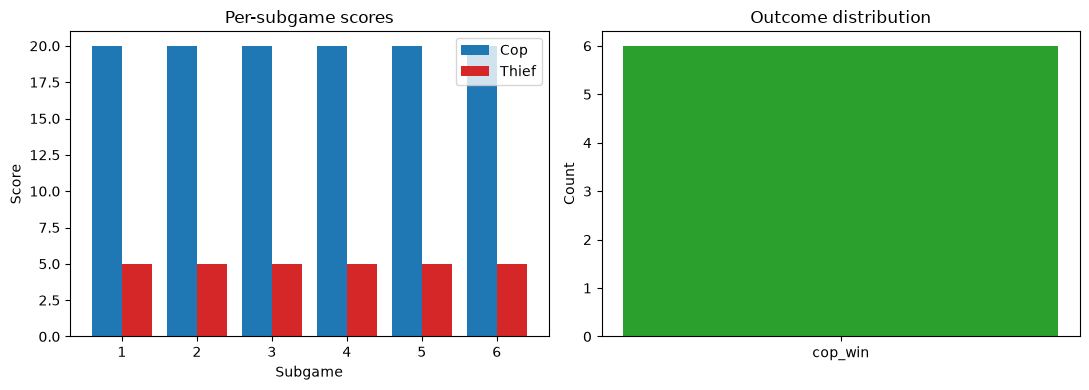

In [2]:
reports = sorted(RESULTS.glob("*.json"))
assert reports, "No reports found - run `uv run copthief selfplay` first."
report = json.loads(reports[-1].read_text(encoding="utf-8"))
sub = report["sub_games"]
print("loaded:", reports[-1].name, "| totals:", report["totals"])

idx = [s["index"] for s in sub]
cop = [s["cop_score"] for s in sub]
thief = [s["thief_score"] for s in sub]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
width = 0.4
ax1.bar([i - width / 2 for i in idx], cop, width, label="Cop", color="tab:blue")
ax1.bar([i + width / 2 for i in idx], thief, width, label="Thief", color="tab:red")
ax1.set_xlabel("Subgame")
ax1.set_ylabel("Score")
ax1.set_title("Per-subgame scores")
ax1.legend()

counts = Counter(s["outcome"] for s in sub)
ax2.bar(list(counts.keys()), list(counts.values()), color="tab:green")
ax2.set_title("Outcome distribution")
ax2.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Parameter sweep: grid size vs. cop capture rate

Smaller boards make it far easier for the cop to corner the thief. We run many
self-play subgames per grid size with the heuristic strategy and measure the
fraction the cop wins (a sensitivity analysis over the `grid_size` parameter).

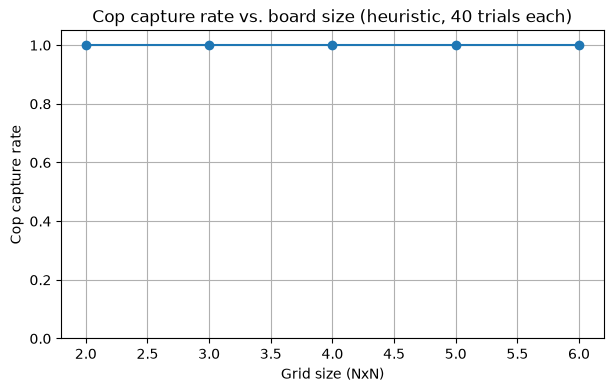

[(2, 1.0), (3, 1.0), (4, 1.0), (5, 1.0), (6, 1.0)]

In [3]:
def capture_rate(size: int, trials: int = 40, seed: int = 0) -> float:
    """Run trials self-play subgames on a size x size board; return cop-win rate."""
    audit = AuditLog(ROOT, {"log_dir": "logs", "game_log_file": "sweep.log"})
    scoring = {"cop_win": 20, "thief_win": 10, "cop_loss": 5, "thief_loss": 5}
    game_cfg = {"grid_size": [size, size], "max_moves": 25, "num_games": trials,
                "max_barriers": 5, "origin": 1, "diagonal_moves": True}
    cop = Agent(Role.COP, HeuristicStrategy(), MockProvider())
    thief = Agent(Role.THIEF, HeuristicStrategy(), MockProvider())
    runner = MatchRunner(game_cfg, scoring, cop, thief, audit, random.Random(seed))
    result = runner.run_match()
    wins = sum(1 for s in result["sub_games"] if s["outcome"] == "cop_win")
    return wins / trials

sizes = [2, 3, 4, 5, 6]
rates = [capture_rate(s) for s in sizes]

plt.figure(figsize=(7, 4))
plt.plot(sizes, rates, marker="o", color="tab:blue")
plt.xlabel("Grid size (NxN)")
plt.ylabel("Cop capture rate")
plt.title("Cop capture rate vs. board size (heuristic, 40 trials each)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()
list(zip(sizes, rates, strict=True))

## 4. Audit-trail sanity check

The audit log is the dispute-resolution evidence trail. Here we confirm it records
every turn and that no illegal move was ever committed by the referee.

In [4]:
lines = []
if AUDIT.exists():
    lines = [json.loads(x) for x in AUDIT.read_text(encoding="utf-8").splitlines()]
events = Counter(e["event"] for e in lines)
turns = [e for e in lines if e["event"] == "turn"]
illegal = [t for t in turns if not t.get("legal", True)]
print("event counts:", dict(events))
print("total turns:", len(turns), "| illegal committed:", len(illegal))
turns[:3]

event counts: {'subgame_start': 55, 'turn': 918, 'subgame_end': 54, 'match_complete': 9, 'turn_net': 60, 'match_complete_net': 1}
total turns: 918 | illegal committed: 0


[{'ts': '2026-06-21T17:11:42.253163+00:00',
  'event': 'turn',
  'index': 1,
  'move': 0,
  'role': 'thief',
  'action': 'move',
  'legal': True,
  'reason': 'ok',
  'cop': [1, 5],
  'thief': [4, 1],
  'message': 'As the thief, thief moves by (1,0) and you are now at cell (4,1); this is move 1 of 25.'},
 {'ts': '2026-06-21T17:11:42.253664+00:00',
  'event': 'turn',
  'index': 1,
  'move': 1,
  'role': 'cop',
  'action': 'move',
  'legal': True,
  'reason': 'ok',
  'cop': [1, 4],
  'thief': [4, 1],
  'message': 'As the cop, cop moves by (0,-1) and you are now at cell (1,4); this is move 1 of 25.'},
 {'ts': '2026-06-21T17:11:42.254164+00:00',
  'event': 'turn',
  'index': 1,
  'move': 1,
  'role': 'thief',
  'action': 'move',
  'legal': True,
  'reason': 'ok',
  'cop': [1, 4],
  'thief': [5, 1],
  'message': 'As the thief, thief moves by (1,0) and you are now at cell (5,1); this is move 2 of 25.'}]